In [3]:
import pandas as pd

# -------------------------------------------------------------
# STEP 1: READ RAW FILES & TAG BRAND (Before Concat)
# -------------------------------------------------------------
df_ny = pd.read_csv("C:/Users/hemanathan/OneDrive/Desktop/guvi hcl/marketing campaign/data/nykaa_campaign_data_with_nulls.csv")
df_py = pd.read_csv("C:/Users/hemanathan/OneDrive/Desktop/guvi hcl/marketing campaign/data/purplle_campaign_data_with_nulls.csv")
df_ti = pd.read_csv("C:/Users/hemanathan/OneDrive/Desktop/guvi hcl/marketing campaign/data/tira_campaign_data_with_nulls.csv")

In [4]:
# Tag them so you know where each row came from
df_ny['Brand'] = 'Nykaa'
df_py['Brand'] = 'Purplle'
df_ti['Brand'] = 'Tira'

In [5]:
# STEP 2: CONCAT FIRST
# -------------------------------------------------------------
master_df = pd.concat([df_ny, df_py, df_ti], ignore_index=True)

In [6]:
# STEP 3: DROP Campaign_ID AND Date

columns_to_drop = ['Campaign_ID', 'Date']

In [7]:
master_df.isnull().sum()

Campaign_ID         5417
Campaign_Type       8358
Target_Audience     8172
Duration            8323
Channel_Used        8282
Impressions         8224
Clicks              8224
Leads               8090
Conversions         8000
Revenue             8304
Acquisition_Cost    8161
ROI                 8298
Language            8299
Engagement_Score    8081
Customer_Segment    8175
Date                8099
Brand                  0
dtype: int64

In [8]:
master_df.head

<bound method NDFrame.head of          Campaign_ID Campaign_Type        Target_Audience  Duration  \
0        NY-CMP-1000  Social Media       College Students      21.0   
1        NY-CMP-1001      Paid Ads  Tier 2 City Customers      18.0   
2        NY-CMP-1002    Influencer                  Youth      23.0   
3        NY-CMP-1003         Email          Working Women      18.0   
4        NY-CMP-1004      Paid Ads       College Students      10.0   
...              ...           ...                    ...       ...   
166660           NaN           NaN  Tier 2 City Customers      11.0   
166661  TI-CMP-56551           SEO          Working Women      20.0   
166662  TI-CMP-56552         Email                    NaN      13.0   
166663           NaN    Influencer       Premium Shoppers      22.0   
166664  TI-CMP-56554      Paid Ads          Working Women       NaN   

                        Channel_Used  Impressions   Clicks   Leads  \
0                  WhatsApp, YouTube      57804

In [9]:
# Strip extra spaces from column names, then drop Campaign_ID and Date
master_df.columns = master_df.columns.str.strip()
master_df = master_df.drop(columns=['Campaign_ID', 'Date'], errors='ignore')

In [10]:
master_df.head(5)

,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Brand
0,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,NaN,6.14,Hindi,20.98,College Students,Nykaa
1,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,Nykaa
2,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.60,NaN,English,25.03,College Students,Nykaa
3,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.07,0.60,Hindi,13.15,NaN,Nykaa
4,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,Hindi,7.29,Tier 2 City Customers,Nykaa


In [11]:
# Fill null values in Revenue with 0
master_df['Revenue'] = master_df['Revenue'].fillna(0)

# Verify no null values remain in Revenue
print(f"Remaining nulls in Revenue: {master_df['Revenue'].isnull().sum()}")

Remaining nulls in Revenue: 0


In [12]:
# 2. Calculate median and fill null values
median_cost = master_df['Acquisition_Cost'].median()
master_df['Acquisition_Cost'] = master_df['Acquisition_Cost'].fillna(median_cost)

In [13]:
master_df.isnull().sum()

Campaign_Type       8358
Target_Audience     8172
Duration            8323
Channel_Used        8282
Impressions         8224
Clicks              8224
Leads               8090
Conversions         8000
Revenue                0
Acquisition_Cost       0
ROI                 8298
Language            8299
Engagement_Score    8081
Customer_Segment    8175
Brand                  0
dtype: int64

In [14]:
import numpy as np

#Drop the existing ROI column if it exists
if 'ROI' in master_df.columns:
    master_df = master_df.drop(columns=['ROI'])


# Calculate new ROI percentage safely (prevents divide-by-zero errors)
master_df['ROI'] = np.where(
    master_df['Acquisition_Cost'] > 0,
    ((master_df['Revenue'] - master_df['Acquisition_Cost']) / master_df['Acquisition_Cost']) * 100,
    0
)

# 4. Round ROI to 2 decimal places for clean reading
master_df['ROI'] = master_df['ROI'].round(2)

# Verify the output
print("✅ New ROI column generated successfully!")
display(master_df[['Revenue', 'Acquisition_Cost', 'ROI']].head())

✅ New ROI column generated successfully!


,Revenue,Acquisition_Cost,ROI
0,1867515.0,208.725,894625.12
1,1046247.0,180.830,578480.43
2,197055.0,90.600,217400.00
3,376906.0,249.070,151225.33
4,518296.0,228.600,226626.16


In [15]:
# 1. Select all categorical (text) columns
categorical_cols = master_df.select_dtypes(include=['object', 'category']).columns

# 2. Fill nulls with mode ONLY in columns that have missing values
for col in categorical_cols:
    null_count = master_df[col].isnull().sum()
    if null_count > 0:
        col_mode = master_df[col].mode()[0]
        master_df[col] = master_df[col].fillna(col_mode)
        print(f"✅ Filled {null_count} nulls in '{col}' with mode: '{col_mode}'")
    else:
        print(f"✨ '{col}' has 0 nulls — skipped!")

# 3. Final verification across the entire dataset
print("\n--- Final Null Value Count ---")
print(master_df.isnull().sum())

C:\Users\hemanathan\AppData\Local\Temp\ipykernel_15300\1846799088.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = master_df.select_dtypes(include=['object', 'category']).columns


✅ Filled 8358 nulls in 'Campaign_Type' with mode: 'Influencer'
✅ Filled 8172 nulls in 'Target_Audience' with mode: 'Premium Shoppers'
✅ Filled 8282 nulls in 'Channel_Used' with mode: 'Email'
✅ Filled 8299 nulls in 'Language' with mode: 'Hindi'
✅ Filled 8175 nulls in 'Customer_Segment' with mode: 'Youth'
✨ 'Brand' has 0 nulls — skipped!

--- Final Null Value Count ---
Campaign_Type          0
Target_Audience        0
Duration            8323
Channel_Used           0
Impressions         8224
Clicks              8224
Leads               8090
Conversions         8000
Revenue                0
Acquisition_Cost       0
Language               0
Engagement_Score    8081
Customer_Segment       0
Brand                  0
ROI                    0
dtype: int64


In [16]:
# 1. Identify all numerical columns (floats and ints)
numerical_cols = master_df.select_dtypes(include=['number']).columns

# 2. Fill missing values with the median for each column
for col in numerical_cols:
    null_count = master_df[col].isnull().sum()
    if null_count > 0:
        col_median = master_df[col].median()
        master_df[col] = master_df[col].fillna(col_median)
        print(f"✅ Filled {null_count} nulls in '{col}' with median: {col_median:.2f}")
    else:
        print(f"✨ '{col}' has 0 nulls — skipped!")

# 3. Double-check total missing values across the entire DataFrame
print("\n--- Final Check: Total Nulls in Entire Master DataFrame ---")
print(f"Total Null Values: {master_df.isnull().sum().sum()}")

✅ Filled 8323 nulls in 'Duration' with median: 17.00
✅ Filled 8224 nulls in 'Impressions' with median: 55113.00
✅ Filled 8224 nulls in 'Clicks' with median: 3908.00
✅ Filled 8090 nulls in 'Leads' with median: 1476.00
✅ Filled 8000 nulls in 'Conversions' with median: 775.00
✨ 'Revenue' has 0 nulls — skipped!
✨ 'Acquisition_Cost' has 0 nulls — skipped!
✅ Filled 8081 nulls in 'Engagement_Score' with median: 13.59
✨ 'ROI' has 0 nulls — skipped!

--- Final Check: Total Nulls in Entire Master DataFrame ---
Total Null Values: 0


In [17]:
master_df.isnull().sum()

Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
Language            0
Engagement_Score    0
Customer_Segment    0
Brand               0
ROI                 0
dtype: int64

In [18]:
master_df.to_csv("final_data.csv", index=False)

print("🎉 Final cleaned DataFrame saved successfully as 'final_data.csv'!")
print(f"Shape: {master_df.shape}")

🎉 Final cleaned DataFrame saved successfully as 'final_data.csv'!
Shape: (166665, 15)


In [19]:
final_data_df = pd.read_csv("final_data.csv")

In [20]:
final_data_df.head

<bound method NDFrame.head of        Campaign_Type        Target_Audience  Duration  \
0       Social Media       College Students      21.0   
1           Paid Ads  Tier 2 City Customers      18.0   
2         Influencer                  Youth      23.0   
3              Email          Working Women      18.0   
4           Paid Ads       College Students      10.0   
...              ...                    ...       ...   
166660    Influencer  Tier 2 City Customers      11.0   
166661           SEO          Working Women      20.0   
166662         Email       Premium Shoppers      13.0   
166663    Influencer       Premium Shoppers      22.0   
166664      Paid Ads          Working Women      17.0   

                        Channel_Used  Impressions   Clicks   Leads  \
0                  WhatsApp, YouTube      57804.0   6156.0  3616.0   
1                            YouTube      91801.0   3321.0  1971.0   
2          WhatsApp, Google, YouTube      15536.0   2182.0   952.0   
3    

In [21]:
final_data_df.iloc[5522]

Campaign_Type                              Email
Target_Audience                    Working Women
Duration                                    29.0
Channel_Used        Facebook, Instagram, YouTube
Impressions                              96182.0
Clicks                                    3599.0
Leads                                     2018.0
Conversions                                714.0
Revenue                                 144942.0
Acquisition_Cost                          108.29
Language                                   Hindi
Engagement_Score                            6.58
Customer_Segment                College Students
Brand                                      Nykaa
ROI                                    133746.15
Name: 5522, dtype: object

In [22]:
final_data_df.duplicated().sum()

np.int64(0)

In [23]:
final_data_df.isnull().sum()

Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
Language            0
Engagement_Score    0
Customer_Segment    0
Brand               0
ROI                 0
dtype: int64

In [24]:
import pandas as pd

# Calculate skewness for numerical columns
skewness = final_data_df.select_dtypes(include=['float64', 'int64']).skew()

# Sort by highest absolute skewness
skewness_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
}).sort_values(by='Skewness', key=abs, ascending=False)

print("==================================================")
print("📊 FEATURE SKEWNESS SUMMARY")
print("==================================================")
print(skewness_df.to_string(index=False))

📊 FEATURE SKEWNESS SUMMARY
         Feature  Skewness
             ROI  7.146829
Acquisition_Cost  5.589166
         Revenue  2.043849
     Conversions  1.661193
           Leads  1.307805
          Clicks  0.876661
Engagement_Score  0.173630
        Duration  0.013605
     Impressions -0.003763


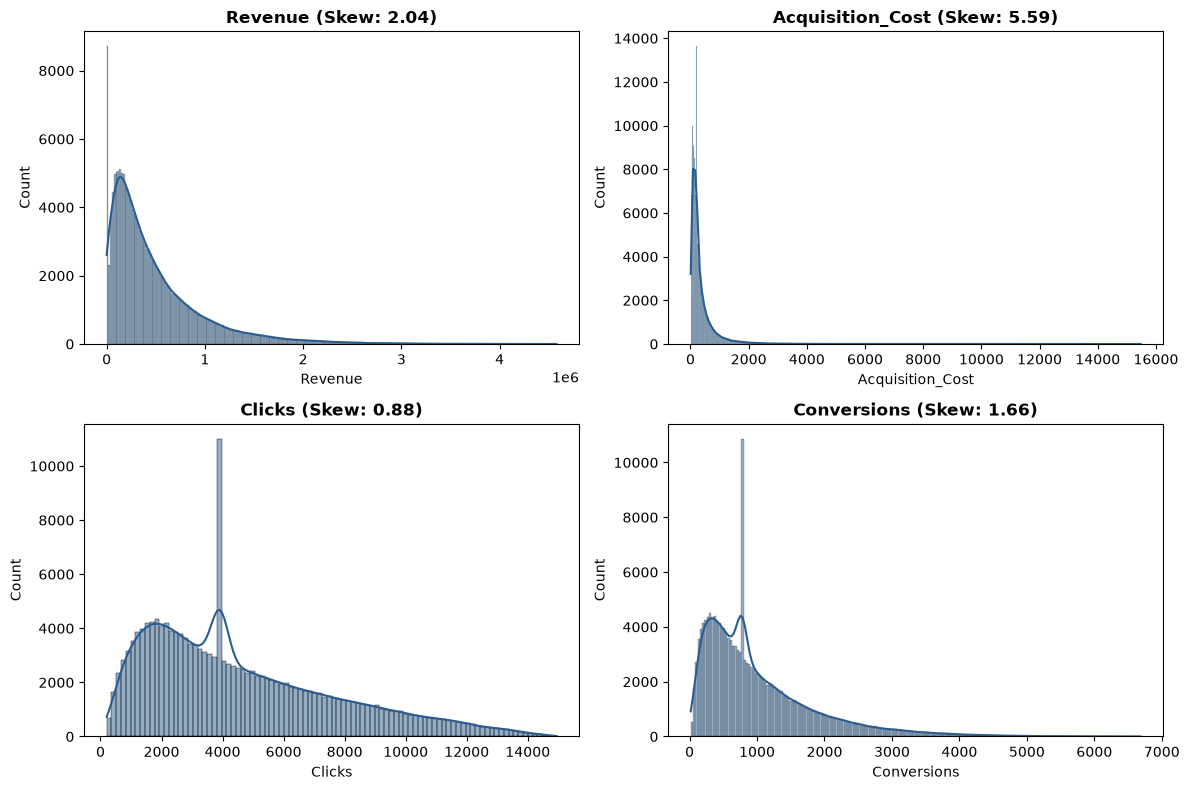

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution for top skewed features
skewed_cols = ['Revenue', 'Acquisition_Cost', 'Clicks', 'Conversions']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    if col in final_data_df.columns:
        sns.histplot(final_data_df[col], kde=True, ax=axes[i], color='#2b5c8f')
        axes[i].set_title(f"{col} (Skew: {final_data_df[col].skew():.2f})", fontweight='bold')

plt.tight_layout()
plt.show()

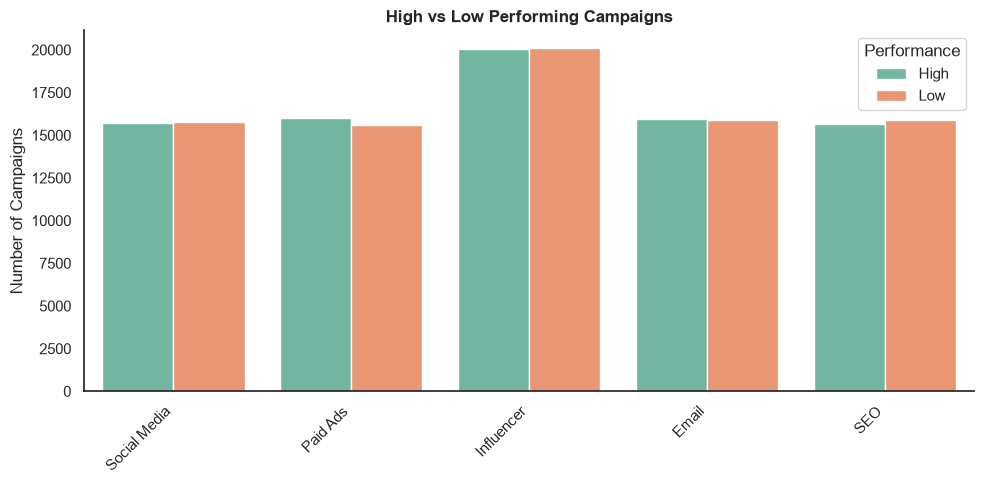

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style='white')

# 1. Calculate median ROI
median_roi = final_data_df['ROI'].median()

# 2. Categorize Performance
final_data_df['Performance'] = np.where(
    final_data_df['ROI'] > median_roi, 'High', 'Low'
)

# 3. Plot Countplot
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=final_data_df, 
    x='Campaign_Type', 
    hue='Performance',
    hue_order=['High', 'Low'],  # Guarantees consistent ordering and color mapping
    palette='Set2'
)

# 4. Formatting Title and Labels
plt.title('High vs Low Performing Campaigns', fontweight='bold', fontsize=12)
plt.xlabel('')  # Clear x-label to prevent clutter if campaign names are self-explanatory
plt.ylabel('Number of Campaigns')

# Rotate campaign labels for readability
plt.xticks(rotation=45, ha='right')

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

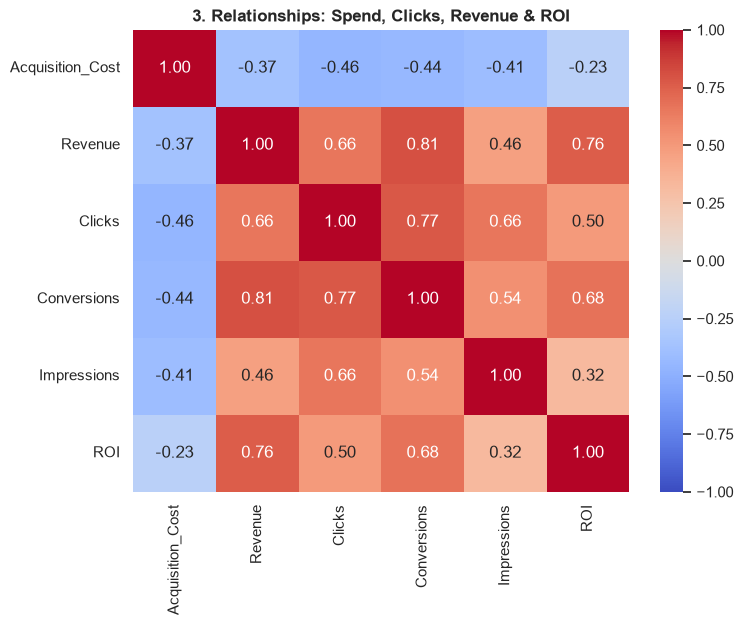

In [27]:
# 3. Correlation Matrix
plt.figure(figsize=(8, 6))
num_cols = ['Acquisition_Cost', 'Revenue', 'Clicks', 'Conversions', 'Impressions', 'ROI']
sns.heatmap(final_data_df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('3. Relationships: Spend, Clicks, Revenue & ROI', fontweight='bold')
plt.show()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


channel_summary = final_data_df.groupby('Channel_Used').agg(
    Campaign_Count=('Channel_Used', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Spend=('Acquisition_Cost', 'sum'),
    Avg_ROI=('ROI', 'mean'),
    Median_ROI=('ROI', 'median'),
    Avg_Clicks=('Clicks', 'mean')
).reset_index().sort_values(by='Avg_ROI', ascending=False)

print(channel_summary.to_string(index=False))

                 Channel_Used  Campaign_Count  Total_Revenue  Total_Spend       Avg_ROI  Median_ROI  Avg_Clicks
       YouTube, Google, Email             429    237399664.0   159262.650 786062.965874  200988.700 4795.426573
       Google, Email, YouTube             471    242299106.0   163130.325 751672.819342  167978.790 4697.900212
  WhatsApp, Instagram, Google             434    228946464.0   149323.310 745836.819217  165520.565 4677.958525
      Google, Facebook, Email             441    235469419.0   156362.935 739609.047234  160730.430 4717.666667
     Instagram, Google, Email             436    237686973.0   149879.955 709018.710849  186566.870 4803.571101
WhatsApp, Instagram, Facebook             450    223034823.0   170349.595 700857.565400  153966.740 4512.317778
     Google, Instagram, Email             456    231073788.0   164221.735 697853.057478  167141.765 4681.519737
 WhatsApp, YouTube, Instagram             430    217234312.0   157915.590 694243.468628  129200.040 4789

C:\Users\hemanathan\AppData\Local\Temp\ipykernel_15300\3057288822.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


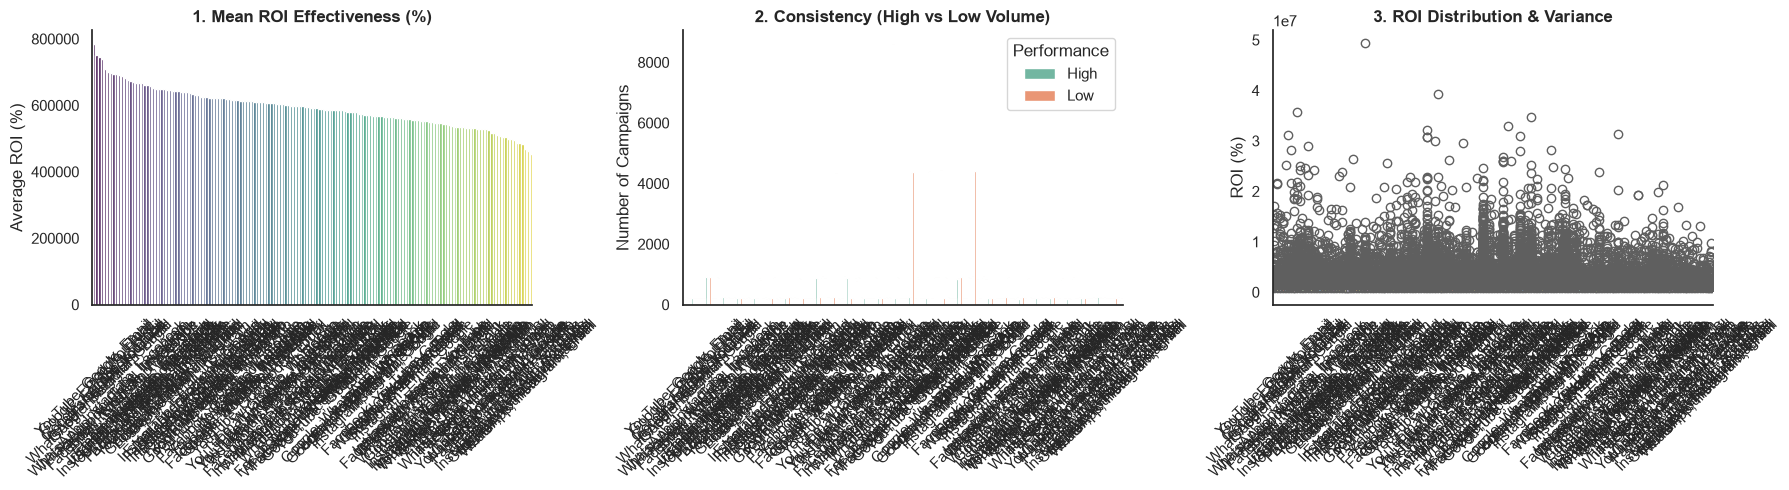

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

final_data_df = pd.read_csv("final_data.csv")

# Set global visual style
sns.set_theme(style='white')
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------
# 1. Data Preparation & Cleaning
# ---------------------------------------------------------
# Ensure standardized channel column name
if 'Channel' in final_data_df.columns and 'Channel_Used' not in final_data_df.columns:
    final_data_df.rename(columns={'Channel': 'Channel_Used'}, inplace=True)

# Select active ROI column
roi_col = 'Calculated_ROI' if 'Calculated_ROI' in final_data_df.columns else 'ROI'

# Flag High vs Low performance relative to Median ROI
median_roi = final_data_df[roi_col].median()
final_data_df['Performance'] = np.where(final_data_df[roi_col] > median_roi, 'High', 'Low')

# Create channel summary aggregated DataFrame
channel_summary = final_data_df.groupby('Channel_Used', as_index=False)[roi_col].mean()
channel_summary.rename(columns={roi_col: 'Avg_ROI'}, inplace=True)
channel_summary = channel_summary.sort_values(by='Avg_ROI', ascending=False)


# ---------------------------------------------------------
# 2. Plotting 3-Panel Dashboard
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Average ROI Effectiveness ---
sns.barplot(
    data=channel_summary, 
    x='Channel_Used', 
    y='Avg_ROI', 
    hue='Channel_Used', 
    palette='viridis', 
    dodge=False, 
    ax=axes[0]
)
axes[0].set_title('1. Mean ROI Effectiveness (%)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Average ROI (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

# --- Chart 2: Consistency (High vs Low Split) ---
sns.countplot(
    data=final_data_df, 
    x='Channel_Used', 
    hue='Performance', 
    hue_order=['High', 'Low'], 
    palette='Set2', 
    order=channel_summary['Channel_Used'], 
    ax=axes[1]
)
axes[1].set_title('2. Consistency (High vs Low Volume)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Campaigns')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# --- Chart 3: ROI Distribution & Outliers ---
sns.boxplot(
    data=final_data_df, 
    x='Channel_Used', 
    y=roi_col, 
    order=channel_summary['Channel_Used'], 
    palette='Set3', 
    ax=axes[2]
)
axes[2].set_title('3. ROI Distribution & Variance', fontweight='bold', fontsize=12)
axes[2].set_ylabel('ROI (%)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()

In [30]:
final_data_df.head()

,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Language,Engagement_Score,Customer_Segment,Brand,ROI,Performance
0,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,208.725,Hindi,20.98,College Students,Nykaa,894625.12,High
1,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,Hindi,7.24,College Students,Nykaa,578480.43,High
2,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.600,English,25.03,College Students,Nykaa,217400.00,High
3,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.070,Hindi,13.15,Youth,Nykaa,151225.33,Low
4,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,Hindi,7.29,Tier 2 City Customers,Nykaa,226626.16,High


In [31]:
#feature engineering
#ENCODING PROCESS
#USING ONE HOT ENCODER FOR CHANNEL USED
#Encoding BY following binary matrix
#MultiLabelBinarizer is designed specifically for multi-label categorical data.

import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Split string lists into Python lists
channels_list = final_data_df['Channel_Used'].apply(lambda x: [item.strip() for item in x.split(',')])

# 2. Fit and transform using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
channel_encoded_df = pd.DataFrame(
    mlb.fit_transform(channels_list),
    columns=mlb.classes_,
    index=final_data_df.index
)

# 3. Concatenate with original DataFrame
df_encoded = pd.concat([final_data_df.drop(columns=['Channel_Used']), channel_encoded_df], axis=1)

print(df_encoded)

       Campaign_Type        Target_Audience  Duration  Impressions   Clicks  \
0       Social Media       College Students      21.0      57804.0   6156.0   
1           Paid Ads  Tier 2 City Customers      18.0      91801.0   3321.0   
2         Influencer                  Youth      23.0      15536.0   2182.0   
3              Email          Working Women      18.0      88114.0   8413.0   
4           Paid Ads       College Students      10.0      96871.0   3743.0   
...              ...                    ...       ...          ...      ...   
166660    Influencer  Tier 2 City Customers      11.0      55113.0   3799.0   
166661           SEO          Working Women      20.0      54886.0   1578.0   
166662         Email       Premium Shoppers      13.0      97954.0  11480.0   
166663    Influencer       Premium Shoppers      22.0      11669.0   3908.0   
166664      Paid Ads          Working Women      17.0      50497.0   1604.0   

         Leads  Conversions    Revenue  Acquisition

In [32]:
df_encoded.head(5)

,Campaign_Type,Target_Audience,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Language,...,Customer_Segment,Brand,ROI,Performance,Email,Facebook,Google,Instagram,WhatsApp,YouTube
0,Social Media,College Students,21.0,57804.0,6156.0,3616.0,2355.0,1867515.0,208.725,Hindi,...,College Students,Nykaa,894625.12,High,0,0,0,0,1,1
1,Paid Ads,Tier 2 City Customers,18.0,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,Hindi,...,College Students,Nykaa,578480.43,High,0,0,0,0,0,1
2,Influencer,Youth,23.0,15536.0,2182.0,952.0,755.0,197055.0,90.600,English,...,College Students,Nykaa,217400.00,High,0,0,1,0,1,1
3,Email,Working Women,18.0,88114.0,8413.0,2231.0,947.0,376906.0,249.070,Hindi,...,Youth,Nykaa,151225.33,Low,0,1,0,1,0,1
4,Paid Ads,College Students,10.0,96871.0,3743.0,2060.0,1258.0,518296.0,228.600,Hindi,...,Tier 2 City Customers,Nykaa,226626.16,High,0,1,0,1,0,0


In [33]:
#Using ordinal encoder for catagorical columns
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Select categorical columns to encode (excluding numerical ones and processed Channel_Used)
categorical_cols = [
    'Campaign_Type', 
    'Target_Audience', 
    'Language', 
    'Customer_Segment', 
    'Brand', 
    'Performance'
]

# Initialize and fit OrdinalEncoder
encoder = OrdinalEncoder()
df_encoded[categorical_cols] = encoder.fit_transform(final_data_df[categorical_cols])

print(df_encoded[categorical_cols])

        Campaign_Type  Target_Audience  Language  Customer_Segment  Brand  \
0                 4.0              0.0       2.0               0.0    0.0   
1                 2.0              2.0       2.0               0.0    0.0   
2                 1.0              4.0       1.0               0.0    0.0   
3                 0.0              3.0       2.0               4.0    0.0   
4                 2.0              0.0       2.0               2.0    0.0   
...               ...              ...       ...               ...    ...   
166660            1.0              2.0       0.0               4.0    2.0   
166661            3.0              3.0       1.0               3.0    2.0   
166662            0.0              1.0       2.0               1.0    2.0   
166663            1.0              1.0       1.0               3.0    2.0   
166664            2.0              3.0       1.0               1.0    2.0   

        Performance  
0               0.0  
1               0.0  
2        

In [34]:
df_encoded.head(5)

,Campaign_Type,Target_Audience,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Language,...,Customer_Segment,Brand,ROI,Performance,Email,Facebook,Google,Instagram,WhatsApp,YouTube
0,4.0,0.0,21.0,57804.0,6156.0,3616.0,2355.0,1867515.0,208.725,2.0,...,0.0,0.0,894625.12,0.0,0,0,0,0,1,1
1,2.0,2.0,18.0,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,2.0,...,0.0,0.0,578480.43,0.0,0,0,0,0,0,1
2,1.0,4.0,23.0,15536.0,2182.0,952.0,755.0,197055.0,90.600,1.0,...,0.0,0.0,217400.00,0.0,0,0,1,0,1,1
3,0.0,3.0,18.0,88114.0,8413.0,2231.0,947.0,376906.0,249.070,2.0,...,4.0,0.0,151225.33,1.0,0,1,0,1,0,1
4,2.0,0.0,10.0,96871.0,3743.0,2060.0,1258.0,518296.0,228.600,2.0,...,2.0,0.0,226626.16,0.0,0,1,0,1,0,0


In [35]:
for col in df_encoded.columns:
    print(col)

Campaign_Type
Target_Audience
Duration
Impressions
Clicks
Leads
Conversions
Revenue
Acquisition_Cost
Language
Engagement_Score
Customer_Segment
Brand
ROI
Performance
Email
Facebook
Google
Instagram
WhatsApp
YouTube


In [36]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 166665 entries, 0 to 166664
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_Type     166665 non-null  float64
 1   Target_Audience   166665 non-null  float64
 2   Duration          166665 non-null  float64
 3   Impressions       166665 non-null  float64
 4   Clicks            166665 non-null  float64
 5   Leads             166665 non-null  float64
 6   Conversions       166665 non-null  float64
 7   Revenue           166665 non-null  float64
 8   Acquisition_Cost  166665 non-null  float64
 9   Language          166665 non-null  float64
 10  Engagement_Score  166665 non-null  float64
 11  Customer_Segment  166665 non-null  float64
 12  Brand             166665 non-null  float64
 13  ROI               166665 non-null  float64
 14  Performance       166665 non-null  float64
 15  Email             166665 non-null  int64  
 16  Facebook          166665 non-nu

In [37]:
#profit/loss flag
df_encoded['Profit_Loss_Flag'] = (df_encoded['ROI'] > 0).astype(int)
# View exact counts and preview the new column
print("Target Distribution:\n", df_encoded['Profit_Loss_Flag'].value_counts())
df_encoded[['ROI', 'Profit_Loss_Flag']].head()

Target Distribution:
 Profit_Loss_Flag
1    158350
0      8315
Name: count, dtype: int64


,ROI,Profit_Loss_Flag
0,894625.12,1
1,578480.43,1
2,217400.00,1
3,151225.33,1
4,226626.16,1


In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. DEFINE TARGET & PREDICTORS (EXPLICIT LISTING)
# ==========================================

# Target Variable (y)
y = df_encoded['Revenue']

# Exclude only direct targets/flags, retaining ROI in predictors
leakage_cols = ['Revenue', 'Profit_Loss_Flag', 'Profit']

# Feature Matrix (X)
X = df_encoded.drop(columns=[col for col in leakage_cols if col in df_encoded.columns])

# ==========================================
# PRINT LIST OF TARGET & FEATURES
# ==========================================
print("==========================================")
print("🎯 TARGET VARIABLE (y):")
print(f"  • ['Revenue']")
print("\n🛡️ FEATURE MATRIX (X) - PREDICTORS INCLUDED:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n📊 Total Predictor Features: {X.shape[1]}")
print("==========================================\n")


# ==========================================
# 2. TRAIN-TEST SPLIT (80/20 Train-Test)
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


# ==========================================
# 3. FEATURE TRANSFORMATION (StandardScaling)
# ==========================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("✅ Feature transformation complete! Continuous features standardized (Mean=0, Std=1).")

🎯 TARGET VARIABLE (y):
  • ['Revenue']

🛡️ FEATURE MATRIX (X) - PREDICTORS INCLUDED:
   1. Campaign_Type
   2. Target_Audience
   3. Duration
   4. Impressions
   5. Clicks
   6. Leads
   7. Conversions
   8. Acquisition_Cost
   9. Language
  10. Engagement_Score
  11. Customer_Segment
  12. Brand
  13. ROI
  14. Performance
  15. Email
  16. Facebook
  17. Google
  18. Instagram
  19. WhatsApp
  20. YouTube

📊 Total Predictor Features: 20

✅ Feature transformation complete! Continuous features standardized (Mean=0, Std=1).


In [39]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

print("==========================================")
print("📈 REGRESSION PERFORMANCE METRICS (REVENUE)")
print("==========================================")

for name, model in reg_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print(f"🔹 {name}")
    print(f"   • R² Score : {r2:.4f}")
    print(f"   • MAE      : ${mae:,.2f}")
    print(f"   • RMSE     : ${rmse:,.2f}\n")

📈 REGRESSION PERFORMANCE METRICS (REVENUE)
🔹 Linear Regression
   • R² Score : 0.7889
   • MAE      : $148,109.87
   • RMSE     : $224,282.46

🔹 Decision Tree Regressor
   • R² Score : 0.8963
   • MAE      : $88,892.33
   • RMSE     : $157,192.73

🔹 Random Forest Regressor
   • R² Score : 0.9270
   • MAE      : $74,629.56
   • RMSE     : $131,838.11



In [40]:
#Hyperparameter-Tuned Random Forest
#selected random forest regressor for its r2 score
#tuning to get more accuracy

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# HYPERPARAMETER-TUNED RANDOM FOREST REGRESSOR
# ==========================================
print("🚀 Training Tuned Random Forest Regressor...")

# Deeper trees (max_depth=15 or None) allow capturing complex non-linear interactions
rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,            # Expanded depth from 5 to 15
    min_samples_split=3,     # Finer node splitting
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Fit on standardized training data
rf_tuned.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_rf = rf_tuned.predict(X_test_scaled)

# Metrics
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n==========================================")
print("📈 TUNED RANDOM FOREST REGRESSION METRICS")
print("==========================================")
print(f"  • R² Score : {r2:.4f}")
print(f"  • MAE      : ${mae:,.2f}")
print(f"  • RMSE     : ${rmse:,.2f}")
print("==========================================\n")

🚀 Training Tuned Random Forest Regressor...

📈 TUNED RANDOM FOREST REGRESSION METRICS
  • R² Score : 0.9993
  • MAE      : $2,341.06
  • RMSE     : $12,734.58



In [41]:
#Classification Models (Predicting Profit/Loss)

# Target Variable (1 = Profit, 0 = Loss)
y_cls = df_encoded['Profit_Loss_Flag']

# STRICTLY EXCLUDE ROI and all post-campaign financial leakage columns
leakage_cols_cls = [
    'Profit_Loss_Flag', 'ROI',  'Profit', 
    'Acquisition_Cost', 'Performance'
]

# Predictor Matrix (X)
X_cls = df_encoded.drop(columns=[col for col in leakage_cols_cls if col in df_encoded.columns])

print("==========================================")
print("🛡️ CLASSIFICATION SETUP (NO LEAKAGE)")
print("==========================================")
print(f"🎯 Target ($y$) : 'Profit_Loss_Flag' | Shape: {y_cls.shape}")
print(f"🛡️ Predictors ($X$): {X_cls.shape[1]} columns (ROI strictly excluded)")
print(f"📋 Included Features:\n{list(X_cls.columns)}")
print("==========================================")

🛡️ CLASSIFICATION SETUP (NO LEAKAGE)
🎯 Target ($y$) : 'Profit_Loss_Flag' | Shape: (166665,)
🛡️ Predictors ($X$): 18 columns (ROI strictly excluded)
📋 Included Features:
['Campaign_Type', 'Target_Audience', 'Duration', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Language', 'Engagement_Score', 'Customer_Segment', 'Brand', 'Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Stratified 80/20 Train-Test Split to preserve class proportions
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=42, stratify=y_cls
)

# Standardize continuous predictors
scaler_c = StandardScaler()

X_train_c_scaled = pd.DataFrame(
    scaler_c.fit_transform(X_train_c),
    columns=X_train_c.columns,
    index=X_train_c.index
)

X_test_c_scaled = pd.DataFrame(
    scaler_c.transform(X_test_c),
    columns=X_test_c.columns,
    index=X_test_c.index
)

print("✅ Classification train-test split & scaling complete!")

✅ Classification train-test split & scaling complete!


In [43]:
#Hyperparameter Tuning via GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("🚀 Tuning classification models with 5-Fold Cross Validation...")

# 1. Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid={'C': [0.01, 0.1, 1, 10], 'class_weight': ['balanced']},
    cv=5, scoring='f1_macro', n_jobs=-1
)
lr_grid.fit(X_train_c_scaled, y_train_c)

# 2. Decision Tree Classifier
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={'max_depth': [3, 5, 8, 12], 'min_samples_split': [5, 10, 20], 'class_weight': ['balanced']},
    cv=5, scoring='f1_macro', n_jobs=-1
)
dt_grid.fit(X_train_c_scaled, y_train_c)

# 3. Random Forest Classifier
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={'n_estimators': [100, 200], 'max_depth': [5, 8, 12], 'class_weight': ['balanced', 'balanced_subsample']},
    cv=5, scoring='f1_macro', n_jobs=-1
)
rf_grid.fit(X_train_c_scaled, y_train_c)

print("✅ Model tuning complete!")

🚀 Tuning classification models with 5-Fold Cross Validation...
✅ Model tuning complete!


In [44]:
#Evaluate Classification Models on Unseen Test Data

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

cls_grids = {
    "Logistic Regression": lr_grid,
    "Decision Tree Classifier": dt_grid,
    "Random Forest Classifier": rf_grid
}

print("==========================================")
print("📊 FINAL CLASSIFICATION EVALUATION")
print("==========================================")

for name, grid in cls_grids.items():
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test_c_scaled)
    probs = best_model.predict_proba(X_test_c_scaled)[:, 1]
    auc = roc_auc_score(y_test_c, probs)
    
    print(f"🔹 {name.upper()}")
    print(f"  • Best Parameters : {grid.best_params_}")
    print(f"  • ROC-AUC Score   : {auc:.4f}\n")
    print(classification_report(y_test_c, preds, target_names=['Loss (0)', 'Profit (1)']))
    
    cm = confusion_matrix(y_test_c, preds)
    print("  🧩 Confusion Matrix:")
    print(f"     [[ True Loss  (TN): {cm[0][0]:<5} | False Profit (FP): {cm[0][1]:<5} ]")
    print(f"      [ False Loss (FN): {cm[1][0]:<5} | True Profit  (TP): {cm[1][1]:<5} ]]\n")
    print("-" * 55)  

📊 FINAL CLASSIFICATION EVALUATION
🔹 LOGISTIC REGRESSION
  • Best Parameters : {'C': 10, 'class_weight': 'balanced'}
  • ROC-AUC Score   : 1.0000

              precision    recall  f1-score   support

    Loss (0)       0.97      1.00      0.98      1663
  Profit (1)       1.00      1.00      1.00     31670

    accuracy                           1.00     33333
   macro avg       0.99      1.00      0.99     33333
weighted avg       1.00      1.00      1.00     33333

  🧩 Confusion Matrix:
     [[ True Loss  (TN): 1661  | False Profit (FP): 2     ]
      [ False Loss (FN): 50    | True Profit  (TP): 31620 ]]

-------------------------------------------------------
🔹 DECISION TREE CLASSIFIER
  • Best Parameters : {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5}
  • ROC-AUC Score   : 0.9994

              precision    recall  f1-score   support

    Loss (0)       1.00      1.00      1.00      1663
  Profit (1)       1.00      1.00      1.00     31670

    accuracy   

In [45]:
#The dataset is heavily imbalanced 
# (~95% Profit, ~5% Loss; 31,670 vs. 1,663 in test).
#Apply SMOTE Oversampling on Scaled Training Data

from imblearn.over_sampling import SMOTE

# Instantiate SMOTE with a fixed random state
smote = SMOTE(random_state=42)

# Resample training data only
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_c_scaled, y_train_c)

print("==========================================")
print("⚖️ CLASS BALANCING VIA SMOTE OVERSAMPLING")
print("==========================================")
print(f"Original Training Class Distribution:")
print(f"  • Loss (0)   : {sum(y_train_c == 0):,} rows")
print(f"  • Profit (1) : {sum(y_train_c == 1):,} rows")

print(f"\nResampled Training Class Distribution (SMOTE):")
print(f"  • Loss (0)   : {sum(y_train_resampled == 0):,} rows")
print(f"  • Profit (1) : {sum(y_train_resampled == 1):,} rows")
print("==========================================\n")

⚖️ CLASS BALANCING VIA SMOTE OVERSAMPLING
Original Training Class Distribution:
  • Loss (0)   : 6,652 rows
  • Profit (1) : 126,680 rows

Resampled Training Class Distribution (SMOTE):
  • Loss (0)   : 126,680 rows
  • Profit (1) : 126,680 rows



In [46]:
#Train & Evaluate Classification Models on Oversampled Data
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("🚀 Training classification models on SMOTE-oversampled training data...\n")

# 1. Logistic Regression
lr_smote = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_smote.fit(X_train_resampled, y_train_resampled)

# 2. Decision Tree Classifier
dt_smote = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)
dt_smote.fit(X_train_resampled, y_train_resampled)

# 3. Random Forest Classifier
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_resampled, y_train_resampled)

smote_models = {
    "Logistic Regression (SMOTE)": lr_smote,
    "Decision Tree Classifier (SMOTE)": dt_smote,
    "Random Forest Classifier (SMOTE)": rf_smote
}

print("==========================================")
print("📊 EVALUATION ON UNTOUCHED TEST DATA")
print("==========================================")

for name, model in smote_models.items():
    preds = model.predict(X_test_c_scaled)
    probs = model.predict_proba(X_test_c_scaled)[:, 1]
    auc = roc_auc_score(y_test_c, probs)
    
    print(f"🔹 {name.upper()}")
    print(f"  • ROC-AUC Score : {auc:.4f}\n")
    print(classification_report(y_test_c, preds, target_names=['Loss (0)', 'Profit (1)']))
    
    cm = confusion_matrix(y_test_c, preds)
    print("  🧩 Confusion Matrix:")
    print(f"     [[ True Loss  (TN): {cm[0][0]:<5} | False Profit (FP): {cm[0][1]:<5} ]")
    print(f"      [ False Loss (FN): {cm[1][0]:<5} | True Profit  (TP): {cm[1][1]:<5} ]]\n")
    print("-" * 55)

🚀 Training classification models on SMOTE-oversampled training data...

📊 EVALUATION ON UNTOUCHED TEST DATA
🔹 LOGISTIC REGRESSION (SMOTE)
  • ROC-AUC Score : 1.0000

              precision    recall  f1-score   support

    Loss (0)       0.96      1.00      0.98      1663
  Profit (1)       1.00      1.00      1.00     31670

    accuracy                           1.00     33333
   macro avg       0.98      1.00      0.99     33333
weighted avg       1.00      1.00      1.00     33333

  🧩 Confusion Matrix:
     [[ True Loss  (TN): 1661  | False Profit (FP): 2     ]
      [ False Loss (FN): 76    | True Profit  (TP): 31594 ]]

-------------------------------------------------------
🔹 DECISION TREE CLASSIFIER (SMOTE)
  • ROC-AUC Score : 0.9991

              precision    recall  f1-score   support

    Loss (0)       1.00      1.00      1.00      1663
  Profit (1)       1.00      1.00      1.00     31670

    accuracy                           1.00     33333
   macro avg       1.00   

In [47]:
import pickle

# ==========================================
# 💾 SAVE MODELS & SCALERS WITH PICKLE
# ==========================================

# 1. Save Tuned Random Forest Regressor (Revenue Prediction)
with open('revenue_regressor.pkl', 'wb') as file:
    pickle.dump(rf_tuned, file)

# 2. Save Random Forest Classifier (Profit/Loss Prediction)
with open('profit_classifier.pkl', 'wb') as file:
    pickle.dump(rf_smote, file)

# 3. Save Scalers
with open('regression_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

with open('classification_scaler.pkl', 'wb') as file:
    pickle.dump(scaler_c, file)

# 4. Save Feature Column Names (Crucial for Streamlit input ordering)
feature_metadata = {
    'reg_features': list(X.columns),
    'cls_features': list(X_cls.columns)
}

with open('feature_columns.pkl', 'wb') as file:
    pickle.dump(feature_metadata, file)

print("==========================================")
print("✅ ALL ARTIFACTS SUCCESSFULLY SAVED!")
print("==========================================")
print("  • revenue_regressor.pkl")
print("  • profit_classifier.pkl")
print("  • regression_scaler.pkl")
print("  • classification_scaler.pkl")
print("  • feature_columns.pkl")
print("==========================================")

✅ ALL ARTIFACTS SUCCESSFULLY SAVED!
  • revenue_regressor.pkl
  • profit_classifier.pkl
  • regression_scaler.pkl
  • classification_scaler.pkl
  • feature_columns.pkl


In [ ]:
%%writefile project.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import os
import plotly.graph_objects as go
import plotly.express as px

# ==========================================
# 1. PAGE CONFIGURATION & STYLING
# ==========================================
st.set_page_config(
    page_title="Multi-Brand Marketing Campaign Performance Analysis",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for polished layout and high-contrast KPI cards
st.markdown("""
<style>
    .main { background-color: #f8fafc; }
    .stMetric {
        background-color: #ffffff;
        padding: 18px;
        border-radius: 12px;
        box-shadow: 0 4px 12px rgba(0,0,0,0.05);
        border: 1px solid #e2e8f0;
    }
    .metric-card-positive {
        border-left: 6px solid #10b981 !important;
    }
    .metric-card-negative {
        border-left: 6px solid #ef4444 !important;
    }
    .metric-card-info {
        border-left: 6px solid #3b82f6 !important;
    }
    .status-badge-profit {
        background-color: #d1fae5;
        color: #065f46;
        padding: 8px 16px;
        border-radius: 20px;
        font-weight: 700;
        font-size: 1.1rem;
        display: inline-block;
    }
    .status-badge-loss {
        background-color: #fee2e2;
        color: #991b1b;
        padding: 8px 16px;
        border-radius: 20px;
        font-weight: 700;
        font-size: 1.1rem;
        display: inline-block;
    }
</style>
""", unsafe_allow_html=True)

# ==========================================
# 2. ARTIFACT LOADING WITH FALLBACK ENGINE
# ==========================================
@st.cache_resource
def load_artifacts():
    """Attempts to load pickle models; returns None if files aren't found."""
    try:
        if (os.path.exists('revenue_regressor.pkl') and 
            os.path.exists('profit_classifier.pkl') and 
            os.path.exists('regression_scaler.pkl') and 
            os.path.exists('classification_scaler.pkl') and 
            os.path.exists('feature_columns.pkl')):
            
            with open('revenue_regressor.pkl', 'rb') as f:
                reg_model = pickle.load(f)
            with open('profit_classifier.pkl', 'rb') as f:
                cls_model = pickle.load(f)
            with open('regression_scaler.pkl', 'rb') as f:
                reg_scaler = pickle.load(f)
            with open('classification_scaler.pkl', 'rb') as f:
                cls_scaler = pickle.load(f)
            with open('feature_columns.pkl', 'rb') as f:
                features = pickle.load(f)
                
            return reg_model, cls_model, reg_scaler, cls_scaler, features, True
        else:
            return None, None, None, None, None, False
    except Exception as e:
        st.warning(f"Note: Error loading .pkl models ({e}). Operating in demonstration Mode.")
        return None, None, None, None, None, False

reg_model, cls_model, reg_scaler, cls_scaler, feature_meta, models_loaded = load_artifacts()

# ==========================================
# 3. SIDEBAR - CAMPAIGN INPUTS
# ==========================================
st.sidebar.image("https://img.icons8.com/color/96/000000/bullish.png", width=70)
st.sidebar.title("Campaign Setup")
st.sidebar.write("Configure your marketing parameters to generate ML insights.")

with st.sidebar.expander("📍 Channel & Metadata", expanded=True):
    channel = st.selectbox("Marketing Channel", ['Paid Search', 'Social Media', 'Email Marketing', 'Influencer', 'Display Ads'])
    target_audience = st.selectbox("Target Audience", ['Young Adults (18-24)', 'Working Professionals (25-40)', 'Parents & Families', 'B2B Buyers'])
    language = st.selectbox("Language / Region", ['English', 'Spanish', 'Hindi', 'French', 'German'])

with st.sidebar.expander("💰 Financials & Budget", expanded=True):
    spend = st.number_input("Total Spend ($)", min_value=100.0, value=2500.0, step=100.0)
    target_roi = st.slider("Target ROI Multiplier", min_value=0.5, max_value=10.0, value=2.5, step=0.1)

with st.sidebar.expander("📊 Engagement & Funnel Metrics", expanded=True):
    impressions = st.number_input("Impressions", min_value=1000, value=65000, step=1000)
    clicks = st.number_input("Clicks", min_value=10, value=3200, step=50)
    leads = st.number_input("Leads Generated", min_value=0, value=180, step=10)
    conversions = st.number_input("Conversions / Sales", min_value=0, value=85, step=5)
    engagement_score = st.slider("Engagement Rating (0-10)", min_value=0.0, max_value=10.0, value=6.8, step=0.1)

# ==========================================
# 4. PREPROCESSING & FEATURE ENGINEERING
# ==========================================
# Calculate Derived Features
ctr = (clicks / impressions) * 100 if impressions > 0 else 0.0
cpc = spend / clicks if clicks > 0 else 0.0
cpa = spend / conversions if conversions > 0 else 0.0
conversion_rate = (conversions / clicks) * 100 if clicks > 0 else 0.0

# Encode Categorical Variables
channel_map = {'Paid Search': 0, 'Social Media': 1, 'Email Marketing': 2, 'Influencer': 3, 'Display Ads': 4}
audience_map = {'Young Adults (18-24)': 0, 'Working Professionals (25-40)': 1, 'Parents & Families': 2, 'B2B Buyers': 3}
lang_map = {'English': 0, 'Spanish': 1, 'Hindi': 2, 'French': 3, 'German': 4}

raw_input_dict = {
    'Channel': channel_map[channel],
    'Target_Audience': audience_map[target_audience],
    'Language': lang_map[language],
    'Spend': spend,
    'Impressions': impressions,
    'Clicks': clicks,
    'Leads': leads,
    'Conversions': conversions,
    'Engagement_Score': engagement_score,
    'Target_ROI': target_roi,
    'CTR': ctr,
    'CPC': cpc,
    'CPA': cpa,
    'Conversion_Rate': conversion_rate
}

input_df = pd.DataFrame([raw_input_dict])

# ==========================================
# 5. MODEL PREDICTION INFERENCE
# ==========================================
if models_loaded:
    try:
        # Reorder columns to match expected pickle schema
        reg_cols = feature_meta['reg_features']
        cls_cols = feature_meta['cls_features']
        
        # Fill missing features if any
        reg_inputs = input_df[[c for c in reg_cols if c in input_df.columns]].copy()
        for c in reg_cols:
            if c not in reg_inputs.columns: reg_inputs[c] = 0
        reg_inputs = reg_inputs[reg_cols]
        
        cls_inputs = input_df[[c for c in cls_cols if c in input_df.columns]].copy()
        for c in cls_cols:
            if c not in cls_inputs.columns: cls_inputs[c] = 0
        cls_inputs = cls_inputs[cls_cols]

        # Scale and Predict
        reg_scaled = reg_scaler.transform(reg_inputs)
        pred_revenue = float(reg_model.predict(reg_scaled)[0])

        cls_scaled = cls_scaler.transform(cls_inputs)
        pred_profit_class = int(cls_model.predict(cls_scaled)[0])
        pred_profit_prob = float(cls_model.predict_proba(cls_scaled)[0][1])

    except Exception as e:
        st.error(f"Inference error with pickle model: {e}. Defaulting to heuristic computation.")
        models_loaded = False

if not models_loaded:
    # Heuristic surrogate calculation for standalone testing
    est_aov = 85.0  # Estimated Average Order Value
    pred_revenue = float((conversions * est_aov) + (clicks * engagement_score * 0.25))
    net_diff = pred_revenue - spend
    pred_profit_class = 1 if net_diff > 0 else 0
    # Calculate synthetic probability curve
    margin_ratio = (pred_revenue - spend) / max(spend, 1)
    pred_profit_prob = min(max(1 / (1 + np.exp(-2 * margin_ratio)), 0.05), 0.98)

# Calculated financial outcomes
pred_net_profit = pred_revenue - spend
pred_roi = ((pred_revenue - spend) / spend) * 100 if spend > 0 else 0.0
profit_margin = (pred_net_profit / pred_revenue) * 100 if pred_revenue > 0 else 0.0

# ==========================================
# 6. MAIN DISPLAY & DASHBOARD
# ==========================================
st.title("🎯 Marketing Campaign Decision Engine")
st.markdown("Automated Machine Learning forecast for revenue, ROI, and profitability risk assessment.")

if not models_loaded:
    st.info("💡 **Demonstration Mode Active:** Custom `.pkl` model files were not detected in the working directory. Using heuristic scoring engine. Save your trained `.pkl` models to enable trained predictions.")
else:
    st.success("✅ **Pickle Machine Learning Models Loaded Successfully!**")

st.divider()

# --- KPI METRIC ROW ---
kpi1, kpi2, kpi3, kpi4 = st.columns(4)

with kpi1:
    st.metric(
        label="Predicted Gross Revenue",
        value=f"${pred_revenue:,.2f}",
        delta=f"{((pred_revenue - spend)/spend)*100:+.1f}% vs Spend"
    )

with kpi2:
    st.metric(
        label="Predicted Net Profit / Loss",
        value=f"${pred_net_profit:,.2f}",
        delta=f"${pred_net_profit:,.2f}",
        delta_color="normal" if pred_net_profit >= 0 else "inverse"
    )

with kpi3:
    st.metric(
        label="Forecasted ROI",
        value=f"{pred_roi:+.1f}%",
        delta=f"{pred_roi - (target_roi*100):+.1f}% vs Target"
    )

with kpi4:
    st.write("**Profitability Status**")
    if pred_profit_class == 1:
        st.markdown('<div class="status-badge-profit">🟢 PROFITABLE</div>', unsafe_allow_html=True)
    else:
        st.markdown('<div class="status-badge-loss">🔴 HIGH RISK LOSS</div>', unsafe_allow_html=True)
    st.caption(f"Profit Confidence: **{pred_profit_prob:.1%}**")

st.markdown("---")

# --- DASHBOARD VISUALIZATIONS ---
tab1, tab2, tab3 = st.tabs(["📊 Financial Breakdown", "🔄 Conversion Funnel & Unit Economics", "🔮 What-If Simulator"])

with tab1:
    col1, col2 = st.columns([1.2, 1])
    
    with col1:
        st.subheader("Spend vs. Forecasted Revenue")
        
        # Waterfall / Bar chart for financial flow
        fig_bar = go.Figure(go.Bar(
            x=['Ad Spend', 'Predicted Revenue', 'Net Profit/Loss'],
            y=[spend, pred_revenue, pred_net_profit],
            marker_color=['#64748b', '#3b82f6', '#10b981' if pred_net_profit >= 0 else '#ef4444'],
            text=[f"${spend:,.2f}", f"${pred_revenue:,.2f}", f"${pred_net_profit:,.2f}"],
            textposition='auto',
        ))
        fig_bar.update_layout(
            yaxis_title="USD ($)",
            height=380,
            template="plotly_white",
            margin=dict(l=20, r=20, t=30, b=20)
        )
        st.plotly_chart(fig_bar, use_container_width=True)

    with col2:
        st.subheader("Profitability Gauge")
        
        # Speedometer/Gauge Chart
        fig_gauge = go.Figure(go.Indicator(
            mode="gauge+number",
            value=pred_profit_prob * 100,
            number={'suffix': "%"},
            title={'text': "Probability of Profit"},
            gauge={
                'axis': {'range': [0, 100]},
                'bar': {'color': "#10b981" if pred_profit_prob >= 0.5 else "#ef4444"},
                'steps': [
                    {'range': [0, 40], 'color': "#fee2e2"},
                    {'range': [40, 70], 'color': "#fef3c7"},
                    {'range': [70, 100], 'color': "#d1fae5"}
                ],
                'threshold': {
                    'line': {'color': "black", 'width': 4},
                    'thickness': 0.75,
                    'value': 50
                }
            }
        ))
        fig_gauge.update_layout(height=380, margin=dict(l=20, r=20, t=30, b=20))
        st.plotly_chart(fig_gauge, use_container_width=True)

with tab2:
    c1, c2 = st.columns([1, 1])
    
    with c1:
        st.subheader("Campaign Conversion Funnel")
        funnel_data = dict(
            number=[impressions, clicks, leads, conversions],
            stage=["Impressions", "Clicks", "Leads", "Conversions"]
        )
        fig_funnel = px.funnel(funnel_data, x='number', y='stage', color_discrete_sequence=['#3b82f6'])
        fig_funnel.update_layout(height=380, template="plotly_white")
        st.plotly_chart(fig_funnel, use_container_width=True)
        
    with c2:
        st.subheader("Engineered Unit Metrics")
        
        unit_df = pd.DataFrame({
            'Metric Name': ['Click-Through Rate (CTR)', 'Cost Per Click (CPC)', 'Cost Per Acquisition (CPA)', 'Conversion Rate'],
            'Value': [f"{ctr:.2f}%", f"${cpc:.2f}", f"${cpa:.2f}", f"{conversion_rate:.2f}%"],
            'Benchmark Target': ['> 2.50%', '< $1.20', '< $35.00', '> 2.00%']
        })
        
        st.dataframe(unit_df, hide_index=True, use_container_width=True)
        
        st.markdown("#### Input Parameter Summary")
        st.json({
            'Channel': channel,
            'Target Audience': target_audience,
            'Engagement Rating': engagement_score,
            'Acquisition Spend': f"${spend:,.2f}"
        })

with tab3:
    st.subheader("Interactive Budget & Conversion Multiplier")
    st.write("Simulate how altering ad budget or boosting conversion rate impacts revenue.")
    
    sim_col1, sim_col2 = st.columns(2)
    
    with sim_col1:
        budget_scaler = st.slider("Scale Budget Multiplier", min_value=0.5, max_value=3.0, value=1.0, step=0.1)
    with sim_col2:
        cr_boost = st.slider("Boost Conversion Rate (+%)", min_value=0.0, max_value=5.0, value=0.0, step=0.2)

    # Simulated outputs
    sim_spend = spend * budget_scaler
    sim_conversions = conversions * budget_scaler * (1 + (cr_boost / 100))
    sim_revenue = pred_revenue * budget_scaler * (1 + (cr_boost / 100))
    sim_profit = sim_revenue - sim_spend

    st.markdown("---")
    sc1, sc2, sc3 = st.columns(3)
    sc1.metric("Simulated Spend", f"${sim_spend:,.2f}", f"{(budget_scaler-1)*100:+.0f}%")
    sc2.metric("Simulated Revenue", f"${sim_revenue:,.2f}", f"${sim_revenue - pred_revenue:+,.2f}")
    sc3.metric("Simulated Net Profit", f"${sim_profit:,.2f}", f"${sim_profit - pred_net_profit:+,.2f}",
               delta_color="normal" if sim_profit >= 0 else "inverse")

Writing project.py
